# EMD-Based Schizophrenia Classification on Dataset 1 using Statistical and Entropy Features

This notebook implements an EEG classification pipeline for schizophrenia detection on Dataset 1 using Empirical Mode Decomposition (EMD).

The EEG recordings are segmented into 5-second windows, decomposed into Intrinsic Mode Functions (IMFs), filtered according to a physiologically relevant frequency range, and transformed into feature vectors using statistical and entropy-based descriptors.

The resulting features are then used to train and evaluate machine learning models.

In [2]:
import mne
from glob import glob
from PyEMD import EMD
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import classification_report, accuracy_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import seaborn as sns

## Dataset Loading

The EEG recordings are loaded from EDF files using the MNE library.

Two groups are considered:
- healthy subjects
- schizophrenia patients

Each recording is converted into a numerical array for subsequent signal processing and feature extraction.

In [3]:
def load_eeg(file_path):
    raw = mne.io.read_raw_edf(file_path, preload=True)
    return raw.get_data()

healthy_file_paths = sorted(glob(f"dataverse_files/h*.edf"))
schizo_file_paths = sorted(glob(f"dataverse_files/s*.edf"))
healthy_signals = [load_eeg(file) for file in healthy_file_paths]
schizo_signals = [load_eeg(file) for file in schizo_file_paths]

print(f"Nombre de fichiers sains : {len(healthy_signals)}")
print(f"Nombre de fichiers atteints : {len(schizo_signals)}")

Extracting EDF parameters from /content/dataverse_files/h01.edf...
EDF file detected
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 231249  =      0.000 ...   924.996 secs...
Extracting EDF parameters from /content/dataverse_files/h02.edf...
EDF file detected
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 227499  =      0.000 ...   909.996 secs...
Extracting EDF parameters from /content/dataverse_files/h03.edf...
EDF file detected
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 227499  =      0.000 ...   909.996 secs...
Extracting EDF parameters from /content/dataverse_files/h04.edf...
EDF file detected
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 231249  =      0.000 ...   924.996 secs...
Extracting EDF parameters from /content/dataverse_files/h05.edf...
EDF file detected
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 236249  

## Signal Segmentation

Each EEG recording is divided into 5-second segments using a sampling frequency of 250 Hz.

This segmentation step increases the number of training samples and allows the models to learn from shorter and more localized temporal patterns in the EEG signals.

In [4]:
def segment_signal(signal, segment_duration, fs):
    segment_length = int(segment_duration * fs)
    return [signal[:, i:i + segment_length] for i in range(0, signal.shape[1], segment_length)]

fs = 250
segment_duration = 5

healthy_segments = [segment_signal(sig, segment_duration, fs) for sig in healthy_signals]
schizo_segments = [segment_signal(sig, segment_duration, fs) for sig in schizo_signals]

In [ ]:
def shannon_entropy(signal, num_bins=10):
    histogram, bin_edges = np.histogram(signal, bins=num_bins, density=True)
    probabilities = histogram / np.sum(histogram)
    probabilities = probabilities[probabilities > 0]
    entropy = -np.sum(probabilities * np.log2(probabilities))
    return entropy

def sample_entropy(signal, m=2, r=None):
    if r is None:
        r = 0.2 * np.std(signal)

    N = len(signal)
    if N < m + 1:
        return 0 

    def sliding_window_view(signal, window_size):
        shape = (signal.shape[0] - window_size + 1, window_size)
        strides = (signal.strides[0], signal.strides[0])
        return np.lib.stride_tricks.as_strided(signal, shape=shape, strides=strides)

    xm = sliding_window_view(signal, m)
    xm_next = sliding_window_view(signal, m + 1)

    def count_similar_patterns(arr, r):
        count = 0
        N = arr.shape[0]
        for i in range(N):
            distances = np.abs(arr[i] - arr[i + 1:]) 
            count += np.sum(np.all(distances < r, axis=1))  
        return count

    count_m = count_similar_patterns(xm, r)
    count_m1 = count_similar_patterns(xm_next, r)

    if count_m == 0:
        return 0  
    sampen = -np.log(count_m1 / count_m)
    return sampen

## IMF Selection by Frequency Range

After decomposition, IMFs are selected according to their mean frequency.

Only IMFs whose mean frequency lies in the 0.5–45 Hz range are retained.  
This range is chosen to keep components relevant to EEG analysis while reducing the influence of less informative or noisy oscillations.

In [ ]:
def select_imfs_by_frequency(imfs, fs, freq_range):
    selected_imfs = []
    for imf in imfs:
        fft_freqs = np.fft.rfftfreq(len(imf), d=1/fs) 
        fft_magnitude = np.abs(np.fft.rfft(imf))     
        mean_freq = np.sum(fft_freqs * fft_magnitude) / np.sum(fft_magnitude)
        if freq_range[0] <= mean_freq <= freq_range[1]:
            selected_imfs.append(imf)
    return selected_imfs

def extract_features_from_imfs(imfs):
    features = []
    for imf in imfs:
        mean = np.mean(imf)
        std_dev = np.std(imf)
        energy = np.sum(imf ** 2) / len(imf)
        shannon_ent = shannon_entropy(imf)
        sample_ent = sample_entropy(imf)
        features.extend([mean, std_dev, energy, shannon_ent, sample_ent])
    return features

def decompose_and_extract_by_frequency(signal, fs, freq_range):
    emd = EMD()
    imfs = emd(signal)
    selected_imfs = select_imfs_by_frequency(imfs, fs, freq_range)
    features = extract_features_from_imfs(selected_imfs)
    return features

def decompose_and_extract_multichannel_by_frequency(segment, fs, freq_range):
    all_features = []
    for channel in segment:
        features = decompose_and_extract_by_frequency(channel, fs, freq_range)
        all_features.extend(features)
    return all_features

In [ ]:
freq_range = (0.5, 45)
healthy_features = [
    decompose_and_extract_multichannel_by_frequency(segment, fs, freq_range)
    for patient in healthy_segments
    for segment in patient
]

schizo_features = [
    decompose_and_extract_multichannel_by_frequency(segment, fs, freq_range)
    for patient in schizo_segments
    for segment in patient
]
print(f"Nombre total de segments sains traités : {len(healthy_features)}")
print(f"Nombre total de segments atteints traités : {len(schizo_features)}")

In [ ]:
X = healthy_features + schizo_features
y = [0] * len(healthy_features) + [1] * len(schizo_features)  # 0 = sain, 1 = atteint

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

print(f"Taille de l'ensemble d'entraînement : {len(X_train)}")
print(f"Taille de l'ensemble de test : {len(X_test)}")


Taille de l'ensemble d'entraînement : 4042
Taille de l'ensemble de test : 1733


In [ ]:
max_length = max(len(features) for features in X)
print(f"Longueur maximale des vecteurs de caractéristiques : {max_length}")


Longueur maximale des vecteurs de caractéristiques : 630


In [ ]:
def pad_or_truncate_features(features, target_length):
    current_length = len(features)
    if current_length > target_length:
        return features[:target_length]  # Tronquer si trop long
    elif current_length < target_length:
        return np.pad(features, (0, target_length - current_length), mode='constant')
    return features


In [ ]:
# Uniformiser les longueurs
X_uniform = [pad_or_truncate_features(features, max_length) for features in X]


In [ ]:
X_uniform = np.array(X_uniform)
print(f"Forme de X après uniformisation : {X_uniform.shape}")


Forme de X après uniformisation : (5775, 630)


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X_uniform, y, test_size=0.3, random_state=42)

# Normalisation
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


SVM

In [ ]:


svm = SVC(kernel='rbf', C=1, gamma='scale', random_state=42)
svm.fit(X_train_scaled, y_train)

y_pred = svm.predict(X_test_scaled)


In [ ]:


print("Rapport de classification :")
print(classification_report(y_test, y_pred))

accuracy = accuracy_score(y_test, y_pred)
print(f"Précision globale : {accuracy:.2f}")


Rapport de classification :
              precision    recall  f1-score   support

           0       0.68      0.79      0.73       791
           1       0.80      0.69      0.74       942

    accuracy                           0.74      1733
   macro avg       0.74      0.74      0.74      1733
weighted avg       0.74      0.74      0.74      1733

Précision globale : 0.74


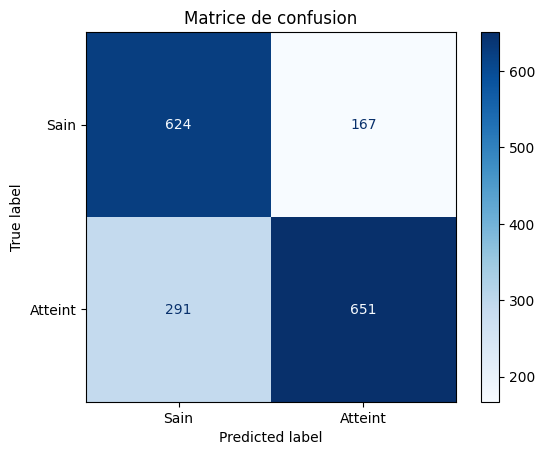

In [ ]:

conf_matrix = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix, display_labels=["Sain", "Atteint"])
disp.plot(cmap=plt.cm.Blues)
plt.title("Matrice de confusion")
plt.show()


Random Forest

Random Forest - Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.88      0.92       791
           1       0.90      0.97      0.94       942

    accuracy                           0.93      1733
   macro avg       0.93      0.92      0.93      1733
weighted avg       0.93      0.93      0.93      1733



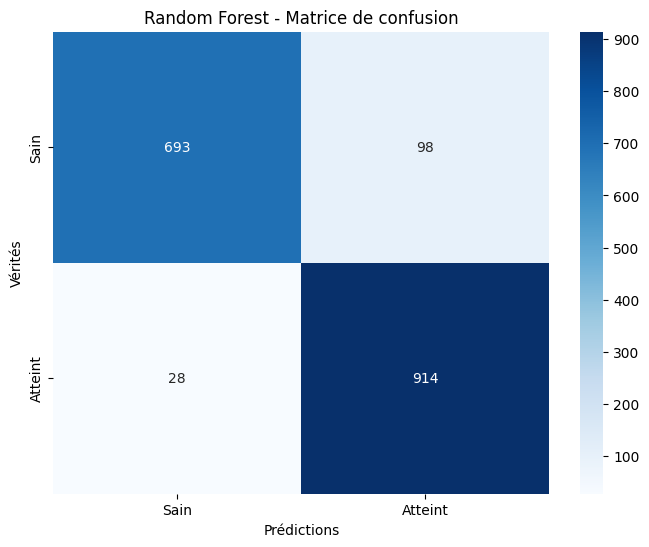

Accuracy: 0.93
Precision: 0.90
Recall: 0.97
F1 Score: 0.94


In [ ]:



rf_clf = RandomForestClassifier(n_estimators=100, random_state=42) 
rf_clf.fit(X_train, y_train)


y_rf_pred = rf_clf.predict(X_test)

print("Random Forest - Classification Report:")
print(classification_report(y_test, y_rf_pred))

conf_matrix_rf = confusion_matrix(y_test, y_rf_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_rf, annot=True, fmt="d", cmap="Blues", xticklabels=["Sain", "Atteint"], yticklabels=["Sain", "Atteint"])
plt.xlabel("Prédictions")
plt.ylabel("Vérités")
plt.title("Random Forest - Matrice de confusion")
plt.show()

accuracy = accuracy_score(y_test, y_rf_pred)
precision = precision_score(y_test, y_rf_pred)
recall = recall_score(y_test, y_rf_pred)
f1 = f1_score(y_test, y_rf_pred)

print(f"Accuracy: {accuracy:.2f}")
print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")
print(f"F1 Score: {f1:.2f}")
